In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

In [3]:
df = pd.read_csv("dogs.csv")

In [4]:
df

,breed,size,energy_level,friendliness,trainability,shedding,barking,lifespan,origin_country,breed_group
0,Labrador Retriever,large,5,5,5,3,3,12,Canada,sporting
1,Chihuahua,small,4,3,2,2,5,14,Mexico,toy
2,German Shepherd,large,5,4,5,4,4,10,Germany,herding
3,Beagle,medium,4,5,3,3,5,13,England,hound
4,Poodle (Standard),medium,3,5,5,2,2,14,Germany/France,non-sporting
5,Bulldog,medium,2,4,3,2,2,9,England,non-sporting
6,Golden Retriever,large,5,5,5,3,3,12,Scotland,sporting
7,Dachshund,small,3,4,3,3,4,13,Germany,hound
8,Boxer,large,4,5,4,3,3,10,Germany,working
9,Shih Tzu,small,2,5,3,2,2,14,China,toy


In [5]:
df = df.set_index(df["breed"]).drop("breed", axis=1)

In [6]:
df

,size,energy_level,friendliness,trainability,shedding,barking,lifespan,origin_country,breed_group
breed,,,,,,,,,
Labrador Retriever,large,5,5,5,3,3,12,Canada,sporting
Chihuahua,small,4,3,2,2,5,14,Mexico,toy
German Shepherd,large,5,4,5,4,4,10,Germany,herding
Beagle,medium,4,5,3,3,5,13,England,hound
Poodle (Standard),medium,3,5,5,2,2,14,Germany/France,non-sporting
Bulldog,medium,2,4,3,2,2,9,England,non-sporting
Golden Retriever,large,5,5,5,3,3,12,Scotland,sporting
Dachshund,small,3,4,3,3,4,13,Germany,hound
Boxer,large,4,5,4,3,3,10,Germany,working


In [7]:
numerics = df.select_dtypes("number").columns.to_list()
categorics = df.select_dtypes(exclude="number").columns.to_list()

In [8]:
categorics

['size', 'origin_country', 'breed_group']

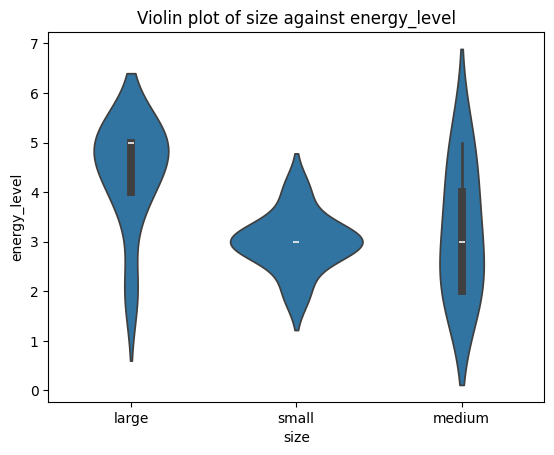

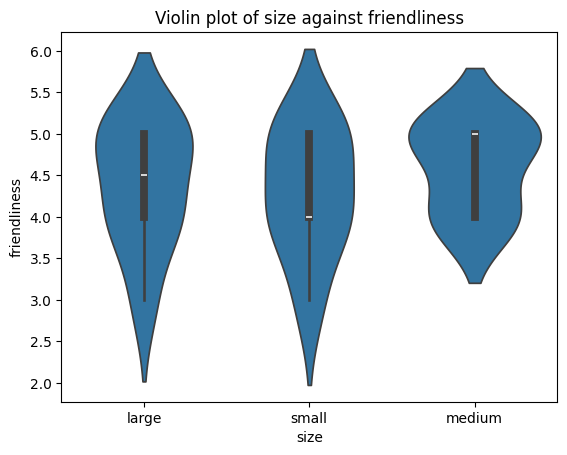

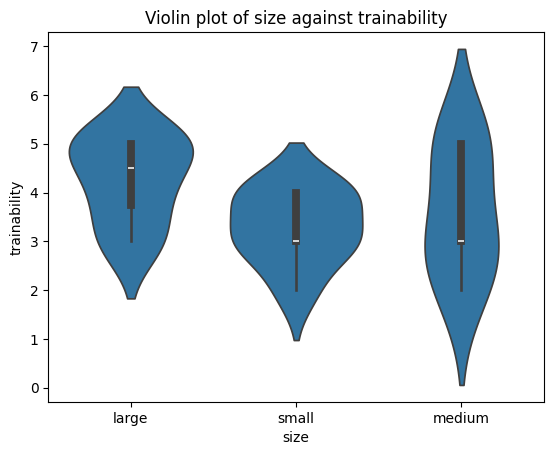

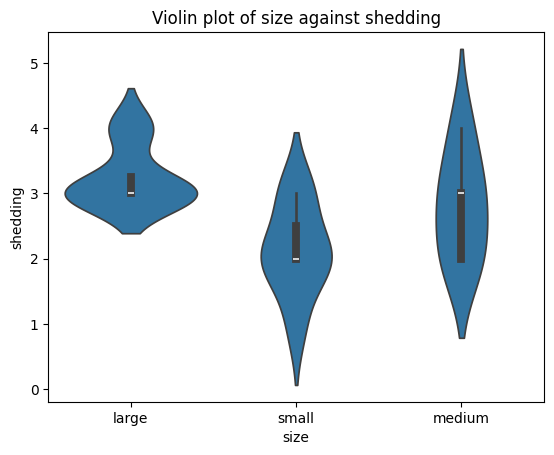

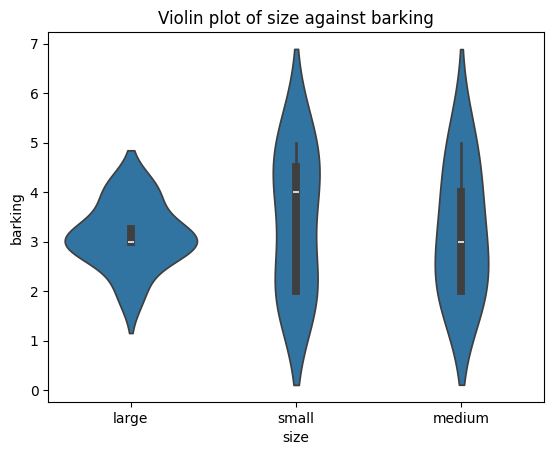

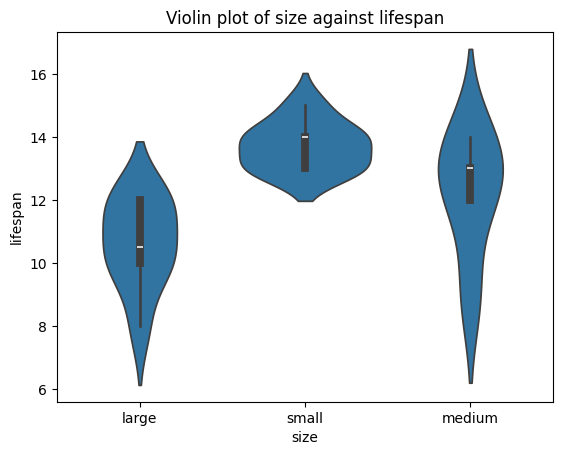

In [9]:
# Plot numerics by size
for feature in numerics:
    sns.violinplot(df, x="size", y=feature)
    plt.title(f"Violin plot of size against {feature}")
    plt.show()

<Axes: xlabel='size', ylabel='count'>

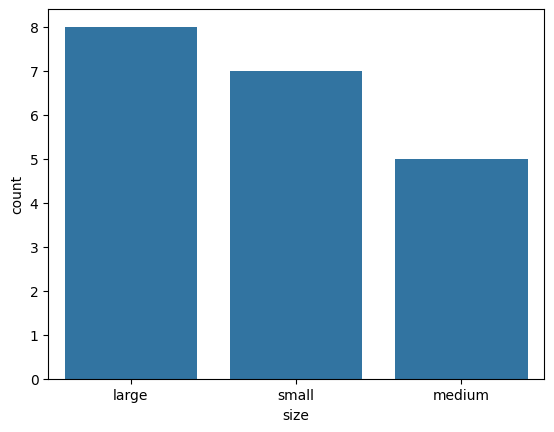

In [10]:
sns.countplot(df, x="size")

# Prepare data for modelling

In [22]:
X = df.drop(["size", "origin_country"], axis=1)
y = df["size"]
y = y.map({"small": 0, "medium": 0, "large": 1})

In [24]:
numerics = X.select_dtypes("number").columns.to_list()
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X[numerics] = scaler.fit_transform(X[numerics])

In [25]:
dummies = pd.get_dummies(X["breed_group"], prefix="breed", drop_first=True, dtype=int)
X = sm.add_constant(pd.concat([X.drop("breed_group", axis=1), dummies], axis=1))

In [26]:
X

,const,energy_level,friendliness,trainability,shedding,barking,lifespan,breed_hound,breed_non-sporting,breed_sporting,breed_toy,breed_working
breed,,,,,,,,,,,,
Labrador Retriever,1.0,1.257237,0.904534,1.257887,0.326164,-0.239732,-0.054313,0,0,1,0,0
Chihuahua,1.0,0.359211,-2.110579,-1.761041,-0.978492,1.678122,1.031938,0,0,0,1,0
German Shepherd,1.0,1.257237,-0.603023,1.257887,1.630820,0.719195,-1.140563,0,0,0,0,0
Beagle,1.0,0.359211,0.904534,-0.754732,0.326164,1.678122,0.488813,1,0,0,0,0
Poodle (Standard),1.0,-0.538816,0.904534,1.257887,-0.978492,-1.198658,1.031938,0,1,0,0,0
Bulldog,1.0,-1.436842,-0.603023,-0.754732,-0.978492,-1.198658,-1.683689,0,1,0,0,0
Golden Retriever,1.0,1.257237,0.904534,1.257887,0.326164,-0.239732,-0.054313,0,0,1,0,0
Dachshund,1.0,-0.538816,-0.603023,-0.754732,0.326164,0.719195,0.488813,1,0,0,0,0
Boxer,1.0,0.359211,0.904534,0.251577,0.326164,-0.239732,-1.140563,0,0,0,0,1


In [29]:
X = X.drop(columns_to_drop, axis=1)

In [30]:
# Fit logistic regression model
logistic_model = sm.Logit(y, X).fit()
print(logistic_model.summary())

         Current function value: 0.000000
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                   size   No. Observations:                   20
Model:                          Logit   Df Residuals:                       13
Method:                           MLE   Df Model:                            6
Date:                Tue, 29 Jul 2025   Pseudo R-squ.:                   1.000
Time:                        21:02:26   Log-Likelihood:            -1.1147e-08
converged:                      False   LL-Null:                       -13.460
Covariance Type:            nonrobust   LLR p-value:                 0.0001499
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -31.4572   4.94e+06  -6.37e-06      1.000   -9.67e+06    9.67e+06
energy_level    38.1617   3.05e+06   1.25e-05      1.000   

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  wa

In [15]:
# Fit MNLogit for class prediction
MN = sm.MNLogit(y, X).fit(maxiter=500)
print(MN.summary())

Optimization terminated successfully.
         Current function value: nan
         Iterations 55
                          MNLogit Regression Results                          
Dep. Variable:                   size   No. Observations:                   20
Model:                        MNLogit   Df Residuals:                       -4
Method:                           MLE   Df Model:                           22
Date:                Tue, 29 Jul 2025   Pseudo R-squ.:                     nan
Time:                        20:58:33   Log-Likelihood:                    nan
converged:                       True   LL-Null:                       -21.611
Covariance Type:            nonrobust   LLR p-value:                       nan
       size=medium       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                     nan        nan        nan        nan         nan         nan
energy_le

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:3027: RuntimeWarning: overflow encountered in exp
  eXB = np.column_stack((np.ones(len(X)), np.exp(X)))
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:3028: RuntimeWarning: invalid value encountered in divide
  return eXB/eXB.sum(1)[:,None]


In [16]:
columns_to_drop = [col for col in X.columns if col.startswith('breed')]
# Fit MNLogit for class prediction
M1 = sm.MNLogit(y, X.drop(columns_to_drop, axis=1)).fit()
print(M1.summary())

         Current function value: 0.000246
         Iterations: 35
                          MNLogit Regression Results                          
Dep. Variable:                   size   No. Observations:                   20
Model:                        MNLogit   Df Residuals:                        6
Method:                           MLE   Df Model:                           12
Date:                Tue, 29 Jul 2025   Pseudo R-squ.:                  0.9998
Time:                        20:58:33   Log-Likelihood:             -0.0049239
converged:                      False   LL-Null:                       -21.611
Covariance Type:            nonrobust   LLR p-value:                 2.079e-05
 size=medium       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           36.7989        nan        nan        nan         nan         nan
energy_level   -32.5919        nan        nan        nan   

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:5475: RuntimeWarning: invalid value encountered in sqrt
  bse = np.sqrt(np.diag(self.cov_params()))


              precision    recall  f1-score   support

       large       1.00      1.00      1.00         8
      medium       1.00      1.00      1.00         5
       small       1.00      1.00      1.00         7

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


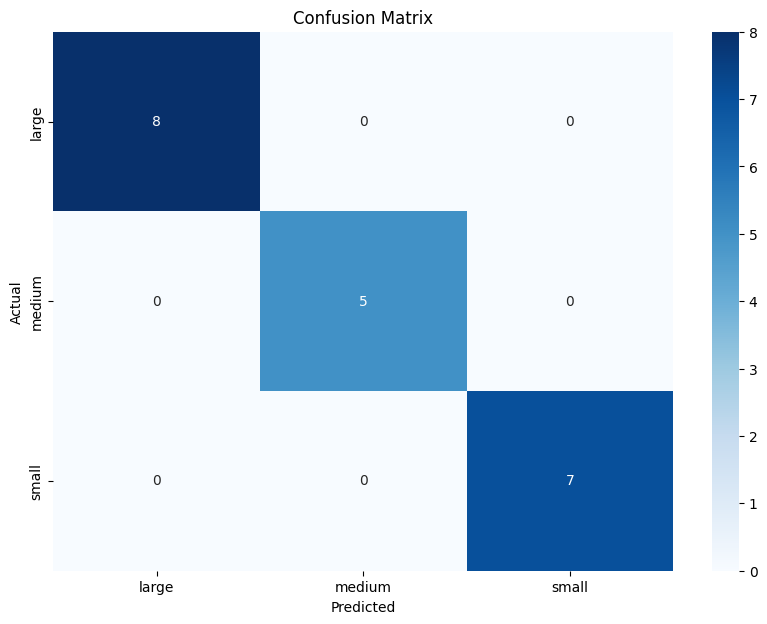

In [17]:
# Fit multi-classifier with sklearn
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=500)
clf.fit(X, y)
# Predict and evaluate
from sklearn.metrics import classification_report, confusion_matrix
y_pred = clf.predict(X)
print(classification_report(y, y_pred))
# Plot confusion matrix
cm = confusion_matrix(y, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()